## NAMA: MUHAMMAD IZZUL ISLAM
## NIM:  F1D02410077

In [1]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
import pandas as pd

Kode di atas mengimpor empat library utama yaitu matplotlib.pyplot untuk visualisasi grafik, cv2 (OpenCV) untuk pemrosesan gambar dan computer vision, numpy untuk komputasi numerik dan manipulasi array, serta pandas untuk analisis data tabular — kombinasi ini mengindikasikan bahwa program akan memproses gambar, menganalisis datanya, lalu memvisualisasikan hasilnya.

In [2]:
water = cv.imread("water.jpg")
graywater = cv.cvtColor(water, cv.COLOR_BGR2GRAY)

Kode di atas membaca file gambar bernama "water.jpg" menggunakan OpenCV dan menyimpannya dalam variabel water, kemudian mengonversi gambar tersebut dari format warna BGR menjadi grayscale (skala abu-abu) menggunakan cv.cvtColor dan menyimpan hasilnya dalam variabel graywater — langkah ini umum dilakukan sebagai preprocessing awal sebelum analisis lebih lanjut, karena gambar grayscale lebih sederhana dan lebih efisien untuk diproses.

In [3]:
def ekualisasi(citra): 
    height, width = citra.shape
    hist = np.zeros(256, dtype=int)
    
    # Hitung histogram
    for i in range(height):
        for j in range(width):
            hist[citra[i][j]] += 1
    
    # Hitung CDF
    cdf = np.zeros(256, dtype=int) 
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
    
    # Normalisasi CDF
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(int)
    
    # Terapkan ke setiap pixel
    hasil = np.zeros_like(citra) 
    for i in range(height):
        for j in range(width):
            hasil[i][j] = cdf_normal[citra[i][j]]
    
    return hasil

Kode di atas mendefinisikan fungsi ekualisasi yang melakukan histogram equalization secara manual pada citra grayscale, dengan cara menghitung histogram frekuensi setiap nilai piksel (0–255), lalu menghitung CDF (Cumulative Distribution Function) untuk mengakumulasi frekuensi tersebut, kemudian menormalisasi CDF ke rentang 0–255, dan akhirnya memetakan setiap nilai piksel asli ke nilai baru berdasarkan CDF yang telah dinormalisasi — tujuan keseluruhan fungsi ini adalah meratakan distribusi kecerahan gambar agar kontras menjadi lebih baik dan detail yang sebelumnya kurang terlihat menjadi lebih jelas.

In [4]:
waterEkualisai = ekualisasi(graywater)

Kode di atas memanggil fungsi ekualisasi yang telah didefinisikan sebelumnya dengan memasukkan variabel graywater (gambar grayscale dari "water.jpg") sebagai argumen, lalu menyimpan hasilnya dalam variabel waterEkualisasi — ini berarti gambar air dalam skala abu-abu kini telah diproses histogram equalization-nya sehingga kontras dan distribusi kecerahan gambar tersebut sudah diratakan dan siap untuk tahap analisis atau visualisasi berikutnya.

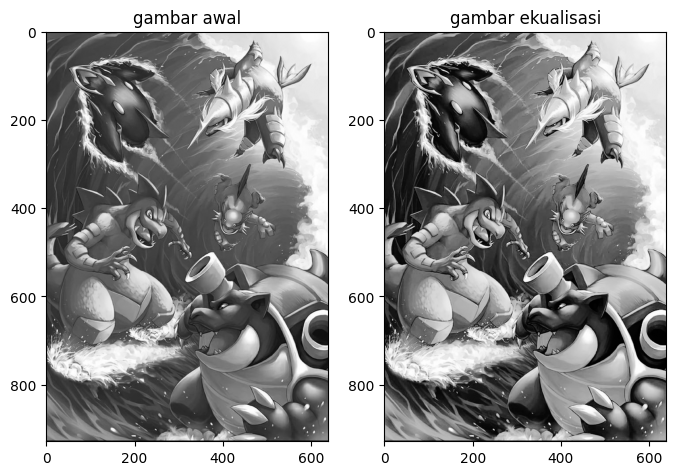

In [5]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("gambar awal")
plt.imshow(graywater, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("gambar ekualisasi")
plt.imshow(waterEkualisai, cmap="gray")

Kode di atas membuat sebuah figure berukuran 8x8 inci yang menampilkan dua gambar secara berdampingan menggunakan plt.subplot(1, 2, ...), di mana subplot pertama menampilkan gambar grayscale asli (graywater) dengan judul "gambar awal" dan subplot kedua menampilkan gambar hasil ekualisasi (waterEkualisasi) dengan judul "gambar ekualisasi" — keduanya ditampilkan dalam colormap abu-abu (cmap="gray") sehingga memudahkan perbandingan visual antara gambar sebelum dan sesudah proses histogram equalization dilakukan.

In [6]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1
 
    return histogram 

def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 

Kode di atas mendefinisikan dua fungsi yaitu buat_hist dan plot_histogram, di mana fungsi pertama bertugas menghitung histogram secara manual dengan cara mengiterasi setiap piksel citra dan menghitung frekuensi kemunculan setiap nilai intensitas (0–255) ke dalam sebuah list berukuran 256, sementara fungsi kedua bertugas memvisualisasikan histogram tersebut dalam bentuk bar chart menggunakan matplotlib dengan sumbu X sebagai intensitas piksel, sumbu Y sebagai jumlah piksel, serta mendukung kustomisasi judul dan warna batang — kedua fungsi ini dirancang untuk bekerja bersama guna menganalisis dan membandingkan distribusi intensitas piksel sebelum dan sesudah proses ekualisasi.

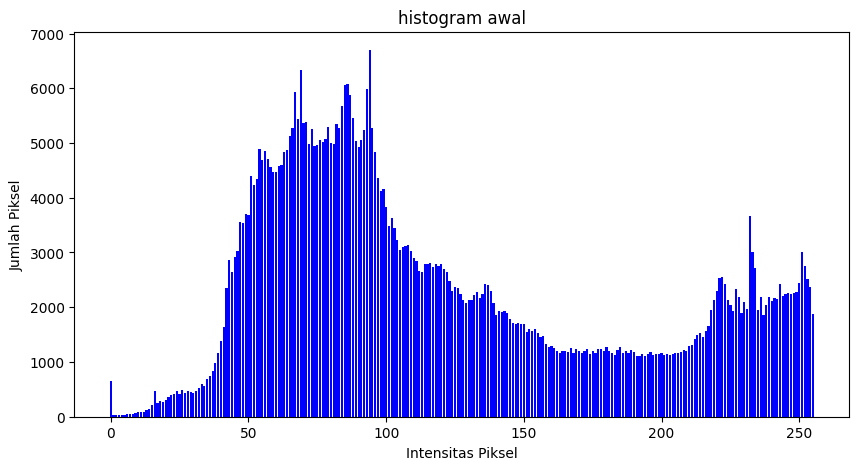

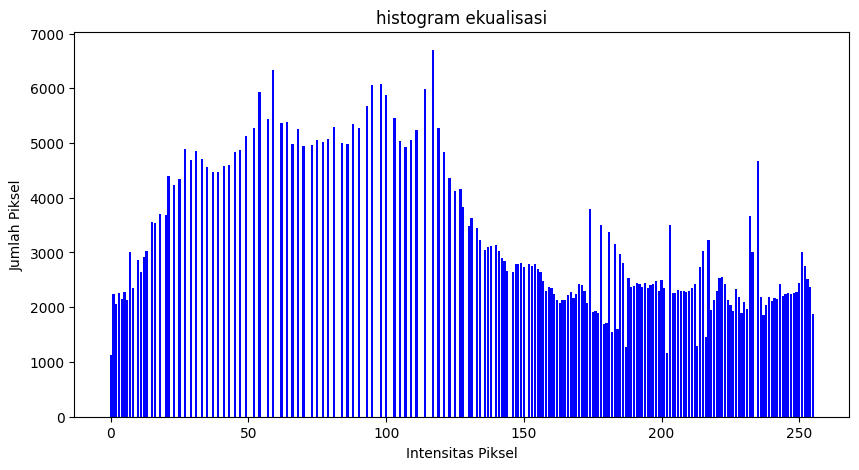

In [7]:
histoAwal = buat_hist(graywater)
plot_histoAwal = plot_histogram(histoAwal, "histogram awal", "blue")
histoEkual = buat_hist(waterEkualisai)
plot_histoEqual = plot_histogram(histoEkual, "histogram ekualisasi", "blue")

Kode di atas memanggil fungsi buat_hist dua kali untuk menghitung histogram dari gambar grayscale asli (graywater) dan gambar hasil ekualisasi (waterEkualisasi), kemudian memanggil fungsi plot_histogram untuk memvisualisasikan keduanya dalam bar chart berwarna biru dengan judul masing-masing "histogram awal" dan "histogram ekualisasi" — tujuan dari langkah ini adalah membandingkan distribusi intensitas piksel sebelum dan sesudah ekualisasi, di mana histogram awal biasanya terlihat menumpuk di rentang tertentu sedangkan histogram hasil ekualisasi diharapkan lebih merata dan tersebar di seluruh rentang 0–255.

In [8]:
def tampil_histogram1(nama_file):
    # Baca CSV
    data = pd.read_csv(nama_file)

    # Ambil data
    intensity = data["Intensity"]
    sum_pixel = data["Sum of Pixel"]

    # Plot histogram
    plt.figure(figsize=(12, 5))
    plt.bar(intensity, sum_pixel, color = 'green')
    plt.title("histogram target 1")
    plt.show()
    

Kode di atas mendefinisikan fungsi tampil_histogram1 yang membaca data histogram dari file CSV menggunakan pandas, kemudian mengambil kolom "Intensity" sebagai sumbu X dan kolom "Sum of Pixel" sebagai sumbu Y, lalu memvisualisasikannya dalam bentuk bar chart berwarna hijau dengan judul "histogram target 1" — pendekatan ini berbeda dari fungsi histogram sebelumnya karena data intensitas piksel tidak dihitung langsung dari gambar melainkan dibaca dari file CSV eksternal, yang mengindikasikan adanya data histogram referensi atau target yang akan digunakan untuk keperluan perbandingan atau proses lebih lanjut seperti histogram matching.

In [9]:
def tampil_histogram2(nama_file):
    # Baca CSV
    data = pd.read_csv(nama_file)

    # Ambil data
    intensity = data["Intensity"]
    sum_pixel = data["Sum of Pixel"]

    # Plot histogram
    plt.figure(figsize=(12, 5))
    plt.bar(intensity, sum_pixel, color = 'red')
    plt.title("histogram target 2")
    plt.show()

Kode di atas mendefinisikan fungsi tampil_histogram2 yang memiliki struktur dan cara kerja identik dengan fungsi tampil_histogram1 sebelumnya — sama-sama membaca file CSV, mengambil kolom "Intensity" dan "Sum of Pixel", lalu memvisualisasikannya dalam bar chart — namun dengan dua perbedaan yaitu warna batang yang digunakan adalah merah ('red') dan judulnya adalah "histogram target 2", yang mengindikasikan bahwa program ini dirancang untuk menangani dan membandingkan dua buah histogram target yang berbeda, kemungkinan sebagai referensi dalam proses histogram matching terhadap gambar air yang telah diproses sebelumnya.

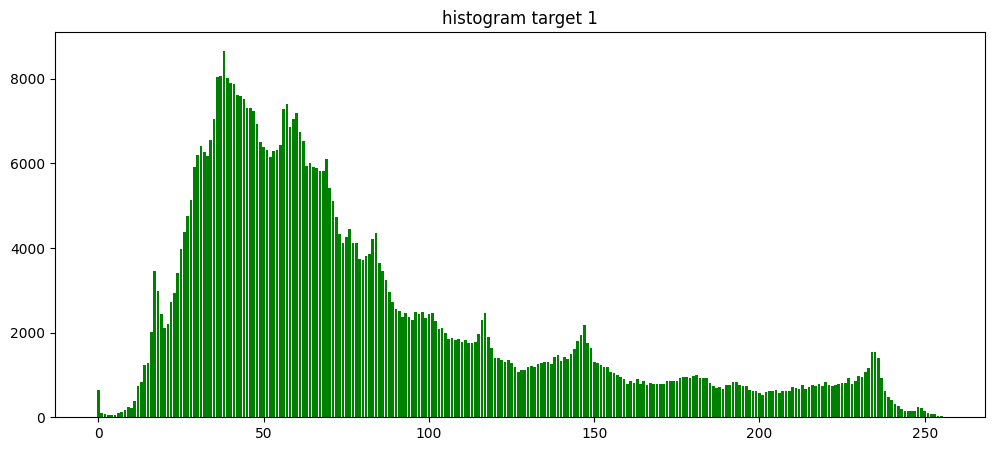

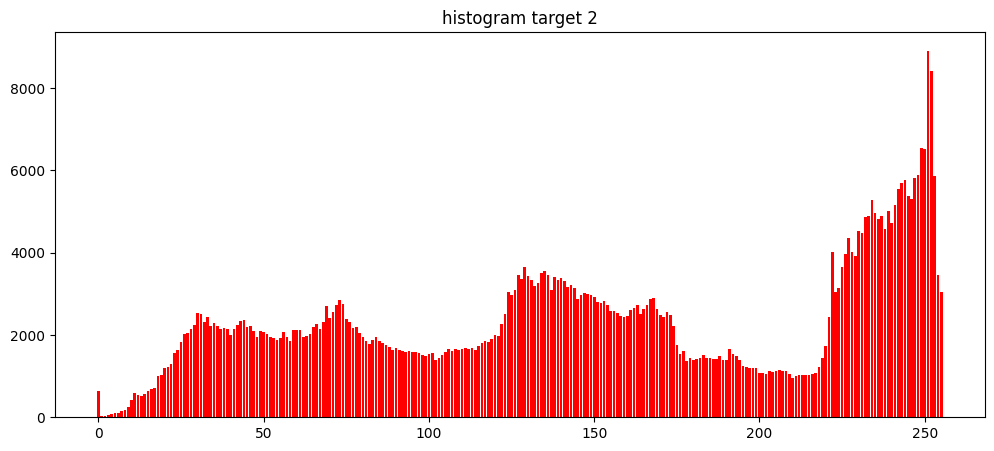

In [10]:
histoTarget1 = tampil_histogram1("target 1.csv")
histoTarget2 = tampil_histogram2("target 2.csv")

Kode di atas memanggil fungsi tampil_histogram1 dan tampil_histogram2 dengan masing-masing membaca file CSV bernama "target 1.csv" dan "target 2.csv", lalu menyimpan hasilnya dalam variabel histoTarget1 dan histoTarget2 — namun perlu diperhatikan bahwa kedua fungsi tersebut hanya menampilkan plot dan tidak mengembalikan nilai apapun (return), sehingga variabel histoTarget1 dan histoTarget2 sebenarnya bernilai None, yang mengindikasikan bahwa variabel-variabel ini tidak dapat digunakan untuk proses komputasi lebih lanjut kecuali fungsinya dimodifikasi terlebih dahulu untuk mengembalikan data histogram.

In [11]:
def spesifikasi_histogram(citra_asal, citra_target): 
    hist_asal = np.zeros(256, dtype=int) 
    hist_target = np.zeros(256, dtype=int) 
 
    # Hitung histogram citra asal
    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            val = int(citra_asal[i][j])
            hist_asal[val] += 1
 
    # Hitung histogram citra target
    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            val = int(citra_target[i][j])
            hist_target[val] += 1
 
    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
 
    # Hitung CDF dari index 1 sampai 255
    for k in range(1, 256):
        cdf_asal[k] = cdf_asal[k-1] + hist_asal[k]
        cdf_target[k] = cdf_target[k-1] + hist_target[k]
 
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
 
    map_hist = np.zeros(256, dtype=np.uint8) 
 
    # Mapping histogram: cari nilai j dengan selisih CDF terkecil
    for i in range(256):
        selisih_min = abs(cdf_asal[i] - cdf_target[0])
        map_hist[i] = 0
        for j in range(1, 256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < selisih_min:
                selisih_min = selisih
                map_hist[i] = j
 
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
 
    # Terapkan mapping ke citra asal
    for i in range(height):
        for j in range(width):
            hasil[i][j] = map_hist[int(citra_asal[i][j])]

    return hasil

Kode di atas mendefinisikan fungsi `spesifikasi_histogram` yang mengimplementasikan teknik histogram matching secara manual, yaitu proses menyesuaikan distribusi intensitas piksel citra asal agar mendekati distribusi intensitas citra target, dengan cara menghitung histogram dan CDF (Cumulative Distribution Function) dari kedua citra kemudian menormalisasikannya ke rentang 0–1, lalu untuk setiap nilai intensitas pada citra asal dicari nilai intensitas pada citra target yang memiliki selisih CDF terkecil sebagai bentuk pemetaan (*mapping*), dan akhirnya pemetaan tersebut diterapkan ke seluruh piksel citra asal untuk menghasilkan citra baru — fungsi ini merupakan inti dari keseluruhan program karena menggabungkan semua proses sebelumnya (ekualisasi, histogram, dan data target) untuk menghasilkan citra yang distribusi warnanya telah disesuaikan dengan referensi target tertentu.

In [12]:
def spesifikasi_histogram_csv(citra_asal, file_csv):

    # Histogram citra asal
    hist_asal = np.zeros(256, dtype=int)

    height, width = citra_asal.shape

    for i in range(height):
        for j in range(width):
            hist_asal[citra_asal[i][j]] += 1

    # Histogram target dari CSV
    data = pd.read_csv(file_csv)

    hist_target = data["Sum of Pixel"].values

    # Hitung CDF
    cdf_asal = np.cumsum(hist_asal).astype(float)
    cdf_target = np.cumsum(hist_target).astype(float)

    # Normalisasi
    cdf_asal /= cdf_asal[-1]
    cdf_target /= cdf_target[-1]

    # Mapping histogram
    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):

        selisih_min = abs(cdf_asal[i] - cdf_target[0])
        map_hist[i] = 0

        for j in range(1, 256):

            selisih = abs(cdf_asal[i] - cdf_target[j])

            if selisih < selisih_min:
                selisih_min = selisih
                map_hist[i] = j

    # Terapkan mapping
    hasil = np.zeros_like(citra_asal)

    for i in range(height):
        for j in range(width):
            hasil[i][j] = map_hist[citra_asal[i][j]]

    return hasil

Kode di atas mendefinisikan fungsi spesifikasi_histogram_csv yang bekerja serupa dengan fungsi spesifikasi_histogram sebelumnya namun dengan perbedaan utama bahwa histogram target tidak berasal dari citra gambar melainkan dibaca langsung dari file CSV melalui kolom "Sum of Pixel" menggunakan pandas, sementara proses selanjutnya tetap sama yaitu menghitung CDF dari histogram citra asal dan target, menormalisasi keduanya, lalu melakukan pemetaan setiap nilai intensitas piksel citra asal ke nilai yang memiliki selisih CDF terkecil dengan target — fungsi ini menjadi versi yang lebih fleksibel karena memungkinkan penggunaan histogram referensi eksternal dari file CSV sebagai target matching, yang menghubungkan langsung dengan data "target 1.csv" dan "target 2.csv" yang telah dibaca sebelumnya.

In [13]:
spesifik1 = spesifikasi_histogram_csv( waterEkualisai, "target 1.csv" )
spesifik2 = spesifikasi_histogram_csv( waterEkualisai, "target 2.csv" )

Kode di atas memanggil fungsi spesifikasi_histogram_csv sebanyak dua kali dengan menggunakan gambar waterEkualisasi sebagai citra asal, namun dengan file target yang berbeda yaitu "target 1.csv" dan "target 2.csv", lalu menyimpan hasilnya masing-masing dalam variabel spesifik1 dan spesifik2 — ini berarti gambar air yang sama akan disesuaikan distribusi intensitasnya terhadap dua referensi histogram yang berbeda secara bersamaan, sehingga menghasilkan dua versi gambar dengan karakteristik kecerahan dan kontras yang berbeda sesuai masing-masing target CSV.

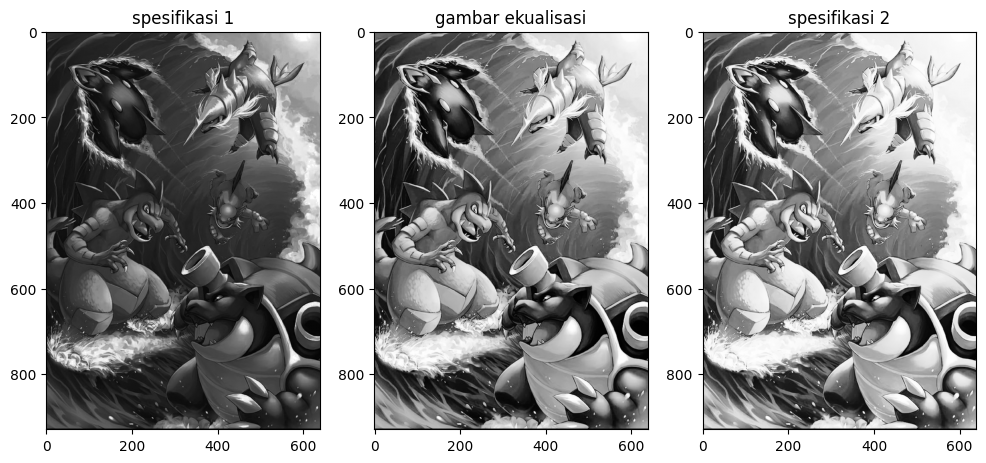

In [14]:
plt.figure(figsize=(12, 8))
plt.subplot(1, 3, 1)
plt.title("spesifikasi 1")
plt.imshow(spesifik1, cmap="gray")

plt.subplot(1, 3, 2)
plt.title("gambar ekualisasi")
plt.imshow(waterEkualisai, cmap="gray")

plt.subplot(1, 3, 3)
plt.title("spesifikasi 2")
plt.imshow(spesifik2, cmap="gray")

Kode di atas membuat sebuah figure berukuran 12x8 inci yang menampilkan tiga gambar secara berdampingan menggunakan plt.subplot(1, 3, ...), di mana subplot pertama menampilkan hasil spesifikasi histogram terhadap target 1 (spesifik1), subplot kedua menampilkan gambar ekualisasi asli (waterEkualisasi) sebagai pembanding di tengah, dan subplot ketiga menampilkan hasil spesifikasi histogram terhadap target 2 (spesifik2) — ketiganya ditampilkan dalam colormap abu-abu sehingga memudahkan perbandingan visual secara langsung antara dua hasil histogram matching yang menggunakan referensi berbeda dengan gambar ekualisasi sebagai acuan tengah, sekaligus menjadi visualisasi penutup dari keseluruhan alur pemrosesan gambar dalam program ini.

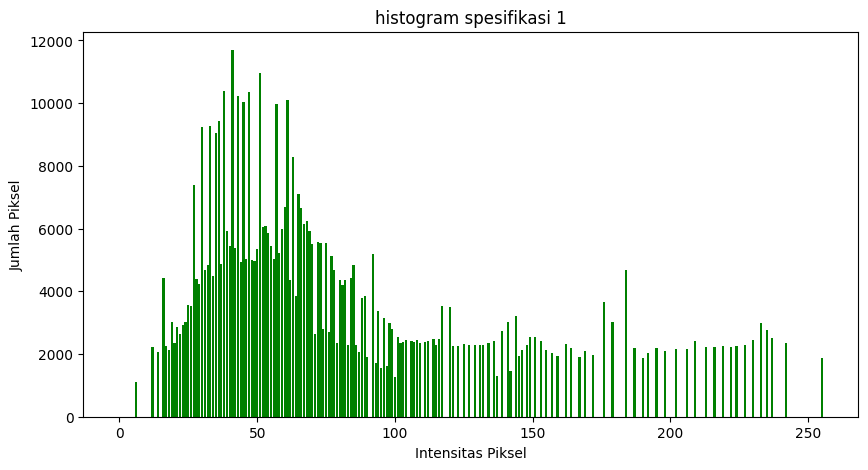

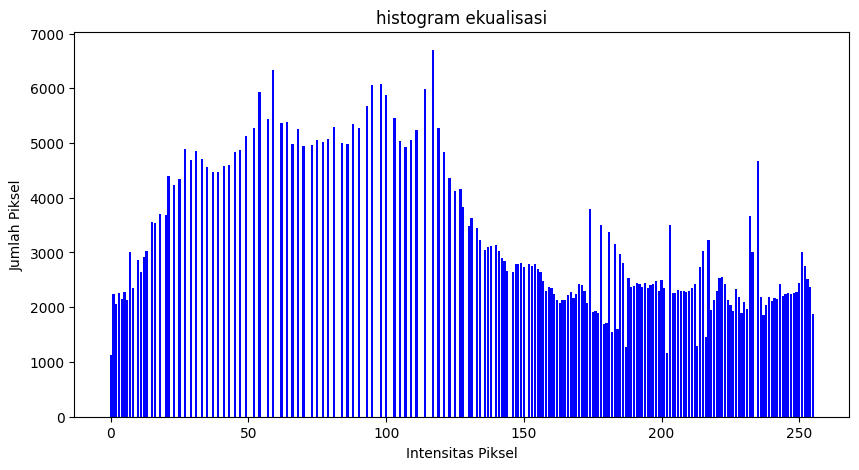

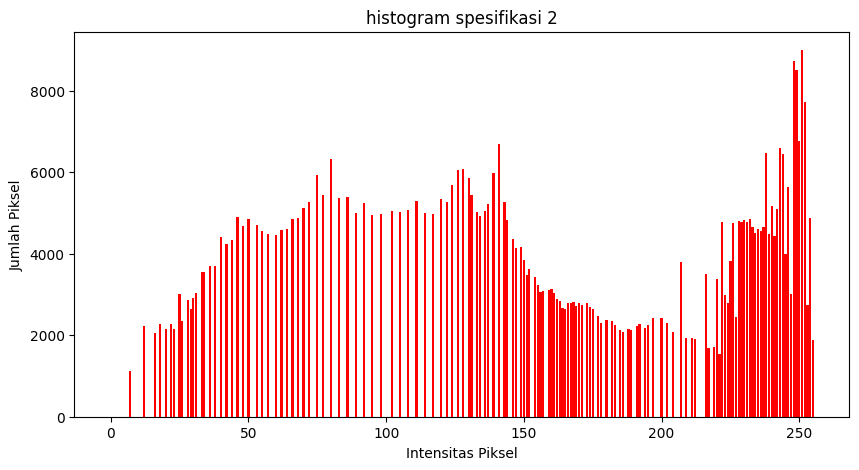

In [15]:
histoSpesifik1 = buat_hist(spesifik1)
plot_histoSpesifik1 = plot_histogram(histoSpesifik1, "histogram spesifikasi 1", "green")
histoEkual = buat_hist(waterEkualisai)
plot_histoEqual = plot_histogram(histoEkual, "histogram ekualisasi", "blue")
histoSpesifik2 = buat_hist(spesifik2)
plot_histoSpesifik2 = plot_histogram(histoSpesifik2, "histogram spesifikasi 2", "red")


Kode di atas memanggil fungsi `buat_hist` dan `plot_histogram` secara bergantian untuk menghitung dan memvisualisasikan histogram dari tiga gambar sekaligus, yaitu `spesifik1` ditampilkan dengan warna hijau dan judul "histogram spesifikasi 1", `waterEkualisasi` dengan warna biru dan judul "histogram ekualisasi", serta `spesifik2` dengan warna merah dan judul "histogram spesifikasi 2" — penggunaan warna yang berbeda untuk setiap histogram mempermudah identifikasi visual, dan langkah ini merupakan tahap evaluasi akhir dari keseluruhan program yang memungkinkan perbandingan distribusi intensitas piksel antara gambar ekualisasi dan kedua hasil histogram matching untuk menilai seberapa jauh distribusi citra hasil telah mendekati masing-masing histogram target yang didefinisikan dalam file CSV.

In [16]:
spesifik1ke2 = spesifikasi_histogram( spesifik1, spesifik2 )
spesifik2ke1 = spesifikasi_histogram( spesifik2, spesifik1 )

Kode di atas memanggil fungsi spesifikasi_histogram sebanyak dua kali dengan menukar posisi citra asal dan citra target, di mana spesifik1ke2 menggunakan spesifik1 sebagai asal dan spesifik2 sebagai target sehingga distribusi intensitas hasil matching target 1 disesuaikan mendekati hasil matching target 2, sementara spesifik2ke1 melakukan kebalikannya yaitu spesifik2 sebagai asal dan spesifik1 sebagai target — eksperimen silang ini bertujuan untuk menganalisis seberapa besar perbedaan karakteristik antara kedua histogram target dan melihat bagaimana gambar berubah ketika dipaksa mengikuti distribusi intensitas satu sama lain, sekaligus menjadi bentuk validasi terhadap konsistensi dan efektivitas fungsi histogram matching yang telah dibangun.

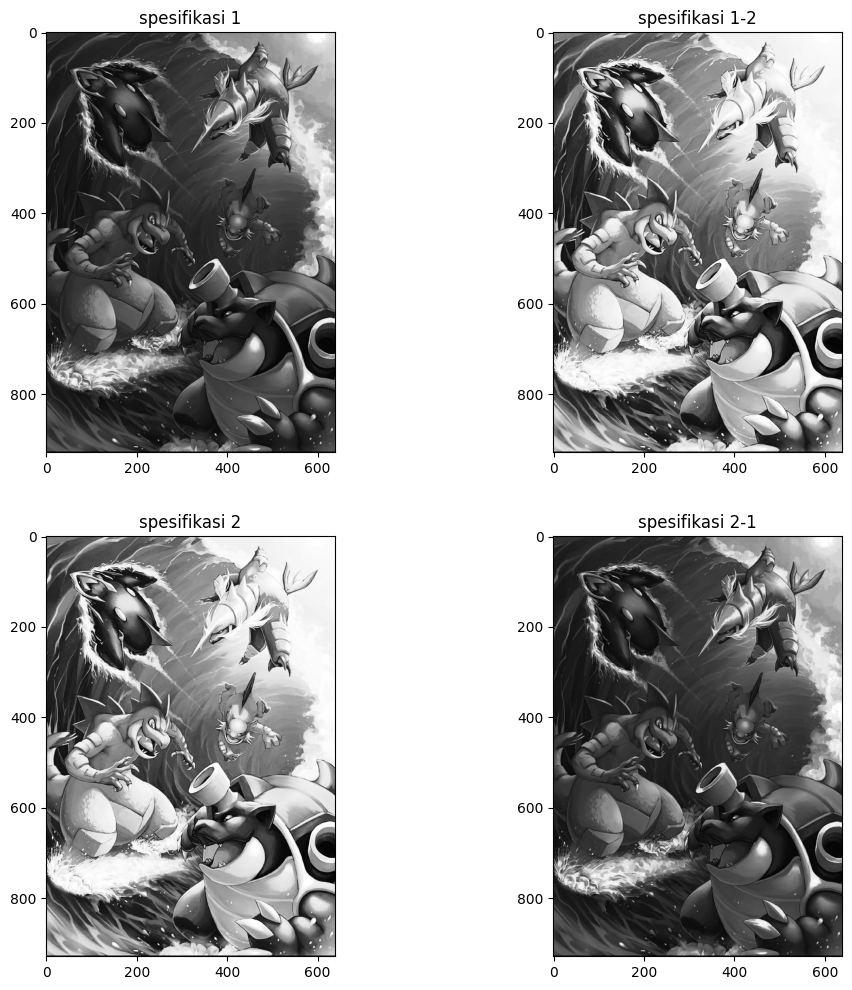

In [17]:
plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
plt.title("spesifikasi 1")
plt.imshow(spesifik1, cmap="gray")

plt.subplot(2, 2, 2)
plt.title("spesifikasi 1-2")
plt.imshow(spesifik1ke2, cmap="gray")

plt.subplot(2, 2, 3)
plt.title("spesifikasi 2")
plt.imshow(spesifik2, cmap="gray")

plt.subplot(2, 2, 4)
plt.title("spesifikasi 2-1")
plt.imshow(spesifik2ke1, cmap="gray")

Kode di atas membuat sebuah figure berukuran 12x12 inci yang menampilkan empat gambar dalam susunan grid 2x2 menggunakan `plt.subplot(2, 2, ...)`, di mana baris pertama menampilkan `spesifik1` (hasil matching ke target 1) dan `spesifik1ke2` (hasil matching dari target 1 ke target 2) secara berdampingan, sementara baris kedua menampilkan `spesifik2` (hasil matching ke target 2) dan `spesifik2ke1` (hasil matching dari target 2 ke target 1) — susunan grid ini dirancang secara simetris untuk memudahkan perbandingan visual secara horizontal maupun vertikal, sehingga dapat terlihat dengan jelas bagaimana perbedaan karakteristik antara kedua target histogram mempengaruhi tampilan gambar ketika proses histogram matching diterapkan secara silang, dan ini merupakan visualisasi komprehensif terakhir yang merangkum seluruh eksperimen pengolahan citra dalam program ini.

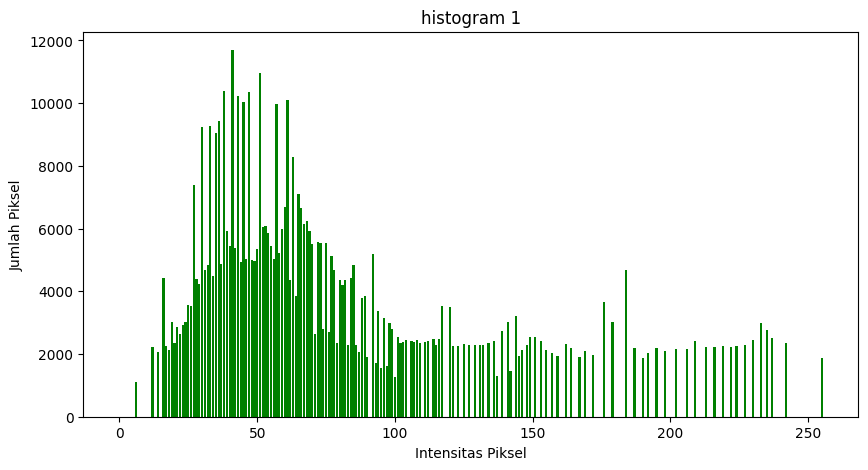

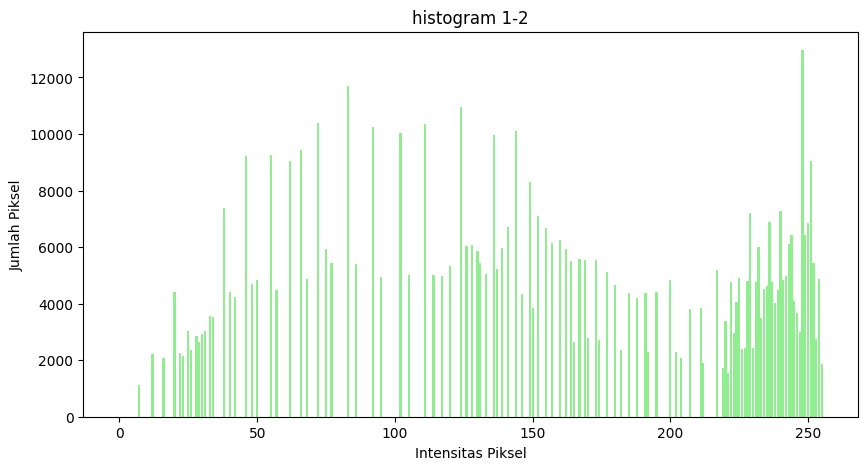

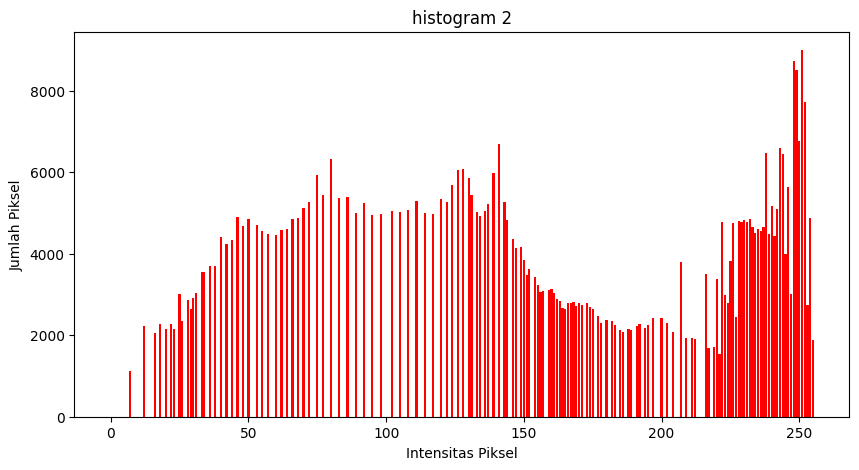

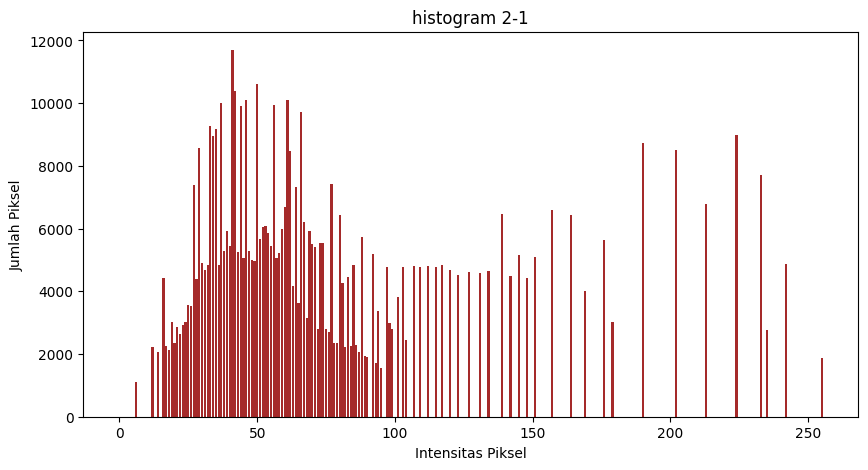

In [19]:
histoSpesifik1 = buat_hist(spesifik1)
plot_histoSpesifik1 = plot_histogram(histoSpesifik1, "histogram 1", "green")
histoSpesifik1ke2 = buat_hist(spesifik1ke2)
plot_histoSpesifik1ke2 = plot_histogram(histoSpesifik1ke2, "histogram 1-2", "lightgreen")
histoSpesifik2 = buat_hist(spesifik2)
plot_histoSpesifik2 = plot_histogram(histoSpesifik2, "histogram 2", "red")
histoSpesifik2ke1 = buat_hist(spesifik2ke1)
plot_histoSpesifik2ke1 = plot_histogram(histoSpesifik2ke1, "histogram 2-1", "brown")

Kode di atas memanggil fungsi `buat_hist` dan `plot_histogram` untuk menghitung dan memvisualisasikan histogram dari keempat gambar hasil eksperimen secara berurutan, yaitu `spesifik1` dengan warna hijau, `spesifik1ke2` dengan warna hijau muda (*lightgreen*), `spesifik2` dengan warna merah, dan `spesifik2ke1` dengan warna coklat — pemilihan warna yang berpasangan (hijau & hijau muda untuk kelompok target 1, merah & coklat untuk kelompok target 2) mencerminkan hubungan kekerabatan antar gambar, dan langkah ini merupakan evaluasi akhir yang paling lengkap dalam program karena memungkinkan analisis perbandingan distribusi intensitas piksel dari keempat gambar sekaligus untuk menilai efek berantai dari proses histogram matching silang yang telah dilakukan sebelumnya.

### KESIMPULAN 

Secara keseluruhan, program ini merupakan implementasi lengkap dari teknik **pengolahan citra digital** berbasis histogram yang mencakup tiga tahap utama yaitu preprocessing, ekualisasi, dan histogram matching. Program dimulai dengan membaca gambar "water.jpg" menggunakan OpenCV dan mengonversinya ke grayscale sebagai langkah preprocessing awal, kemudian menerapkan histogram equalization secara manual melalui fungsi `ekualisasi` yang menghitung histogram, CDF, dan normalisasi piksel satu per satu untuk meratakan distribusi kecerahan gambar agar kontras menjadi lebih baik.

Setelah ekualisasi, program membangun infrastruktur visualisasi histogram melalui fungsi `buat_hist` dan `plot_histogram` yang digunakan secara konsisten di seluruh program untuk menganalisis distribusi intensitas piksel di setiap tahap pemrosesan. Program kemudian memperkenalkan dua histogram target eksternal yang dibaca dari file "target 1.csv" dan "target 2.csv" menggunakan pandas, yang menjadi referensi dalam proses histogram matching melalui dua fungsi utama yaitu `spesifikasi_histogram` untuk matching antar gambar dan `spesifikasi_histogram_csv` untuk matching menggunakan data CSV, keduanya bekerja dengan prinsip yang sama yaitu mencari pemetaan nilai intensitas yang meminimalkan selisih CDF antara citra asal dan target.

Tahap eksperimen utama program ini adalah penerapan histogram matching dari gambar ekualisasi ke dua target CSV secara paralel menghasilkan `spesifik1` dan `spesifik2`, dilanjutkan dengan eksperimen silang (*cross matching*) di mana `spesifik1` di-matching ke `spesifik2` menghasilkan `spesifik1ke2` dan sebaliknya menghasilkan `spesifik2ke1`, sehingga total terdapat empat varian gambar hasil yang semuanya divisualisasikan secara berdampingan dalam grid 2x2 beserta histogram masing-masing dengan kode warna yang berbeda untuk memudahkan identifikasi. Secara keseluruhan, program ini berhasil membangun sebuah pipeline pengolahan citra yang sistematis dan komprehensif, mulai dari pembacaan gambar hingga analisis visual komparatif, dengan mengimplementasikan seluruh algoritma histogram secara manual tanpa bergantung pada fungsi bawaan OpenCV, yang menunjukkan pemahaman mendalam terhadap konsep matematika di balik teknik-teknik pengolahan citra digital.